# Statistical EDA & Hypothesis Testing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu


In [2]:
df = pd.read_parquet("../data/processed/taxi_trip_cleaned.parquet")

## Statistical thinking

In [3]:
df["fare_amount"].mean()
df["fare_amount"].median()
df["trip_distance"].mean()

np.float64(6.455644164334605)

## Sampling

In [4]:
plot_df = df.sample(50000, random_state=42)

In [5]:
plot_df = df.sample(50000, random_state=42)

## Confidence Intervals

In [6]:
df["fare_amount"].mean()

np.float64(20.804241625520014)

## Hypothesis Testing

### Do weekday and weekend trips have different fares?

In [7]:
weekday_fares = df.loc[
    (df["is_weekend"] == False) &
    (df["fare_amount"] > 0),
    "fare_amount"
]

weekend_fares = df.loc[
    (df["is_weekend"] == True) &
    (df["fare_amount"] > 0),
    "fare_amount"
]

print("Weekday observations:", len(weekday_fares))
print("Weekend observations:", len(weekend_fares))

print("\nWeekday mean:", weekday_fares.mean())
print("Weekend mean:", weekend_fares.mean())

print("\nWeekday median:", weekday_fares.median())
print("Weekend median:", weekend_fares.median())

Weekday observations: 2649297
Weekend observations: 1034046

Weekday mean: 21.675512956833455
Weekend mean: 20.344915139171757

Weekday median: 15.6
Weekend median: 15.27


## Visualize the two groups

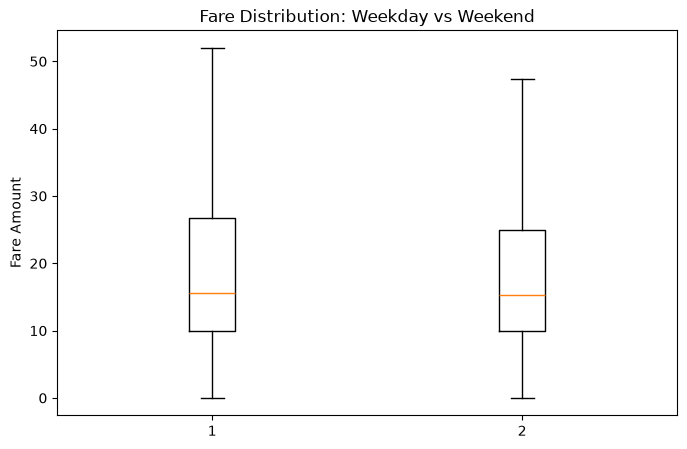

In [9]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [weekday_fares, weekend_fares],
    label=["Weekday", "Weekend"],
    showfliers=False
)

plt.ylabel("Fare Amount")
plt.title("Fare Distribution: Weekday vs Weekend")

plt.show()

## Perform Welch's t-test

In [ ]:
t_stat, p_value = ttest_ind(
    weekday_fares,
    weekend_fares,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 64.88973045801023
p-value: 0.0


## Mann–Whitney U test

In [14]:
u_stat, p_value = mannwhitneyu(
    weekday_fares,
    weekend_fares,
    alternative="two-sided"
)

print("U-statistic:", u_stat)
print("p-value:", p_value)

U-statistic: 1417981751989.5
p-value: 0.0


## Effect Size

In [15]:
mean_difference = weekend_fares.mean() - weekday_fares.mean()

print("Mean difference:", mean_difference)

Mean difference: -1.3305978176616975


In [16]:
percentage_difference = (
    mean_difference / weekday_fares.mean()
) * 100

print("Percentage difference:", percentage_difference)

Percentage difference: -6.1387143192946265


In [7]:
weekday_fares = df.loc[
    (df["is_weekend"] == False) &
    (df["fare_amount"] > 0),
    "fare_amount"
]

weekend_fares = df.loc[
    (df["is_weekend"] == True) &
    (df["fare_amount"] > 0),
    "fare_amount"
]

print("Weekday observations:", len(weekday_fares))
print("Weekend observations:", len(weekend_fares))

print("\nWeekday mean:", weekday_fares.mean())
print("Weekend mean:", weekend_fares.mean())

print("\nWeekday median:", weekday_fares.median())
print("Weekend median:", weekend_fares.median())

Weekday observations: 2649297
Weekend observations: 1034046

Weekday mean: 21.675512956833455
Weekend mean: 20.344915139171757

Weekday median: 15.6
Weekend median: 15.27


### We don't yet know whether the difference is statistically distinguishable from random sampling variation under a particular statistical model.
#
### That's what the hypothesis test will investigate.
#
### Our hypotheses
#
### H₀:
#
### The population mean fare is the same for weekday and weekend trips.
#
### H₁:
#
### The population mean fare differs between weekday and weekend trips.
#
Now let's test it.
#
### Run Welch's t-test


In [8]:
t_stat, p_value = ttest_ind(
    weekday_fares,
    weekend_fares,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 64.88973045801023
p-value: 0.0


In [19]:
print(f"{p_value:.20e}")

0.00000000000000000000e+00


#### p < the numerical precision displayed by the calculation, rather than exactly zero.

## Statistical conclusion

### There is strong statistical evidence of a difference in mean recorded fare between weekday and weekend trips.

## Calculate the relative difference

In [9]:
mean_difference = weekday_fares.mean() - weekend_fares.mean()

percentage_difference = (
    mean_difference / weekend_fares.mean()
) * 100

print("Mean difference:", mean_difference)
print("Percentage difference:", percentage_difference)

Mean difference: 1.3305978176616975
Percentage difference: 6.540198415965801


## Mann–Whitney U test

In [ ]:

u_stat, p_value_mw = mannwhitneyu(
    weekday_fares,
    weekend_fares,
    alternative="two-sided"
)

print("U-statistic:", u_stat)
print("p-value:", p_value_mw)

U-statistic: 1417981751989.5
p-value: 0.0


## let's visualize what the tests are detecting

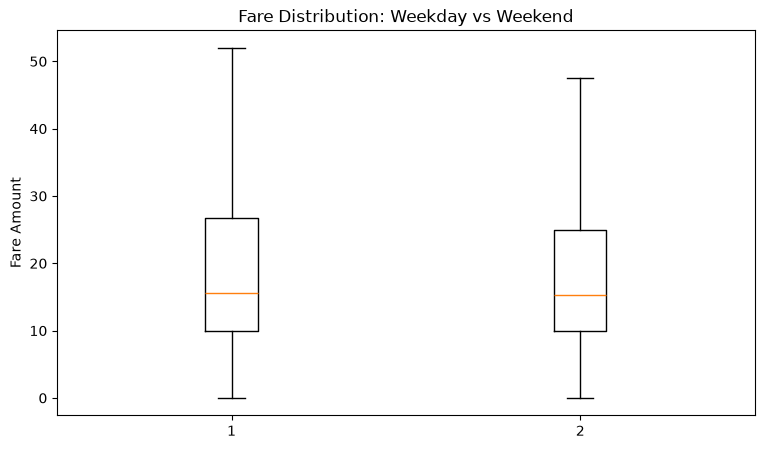

In [10]:
weekday_sample = weekday_fares.sample(
    50000,
    random_state=42
)

weekend_sample = weekend_fares.sample(
    50000,
    random_state=42
)

plt.figure(figsize=(9, 5))

plt.boxplot(
    [weekday_sample, weekend_sample],
    label=["Weekday", "Weekend"],
    showfliers=False
)

plt.ylabel("Fare Amount")
plt.title("Fare Distribution: Weekday vs Weekend")

plt.show()

## Confidence Interval for the Mean Difference

### How precisely have we estimated the difference in mean fare?

In [25]:
pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   --------------- ------------------------ 4.5/11.3 MB 33.0 MB/s eta 0:00:01
   --------------------------- ------------ 7.9/11.3 MB 22.8 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 21.6 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 19.3 MB/s  0:00:00

   ---------------------------------------- 0/5 [wrapt]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   -------------------------------- ------- 4/5 [statsmodels]
   -------------------------------- ------- 4/5 [statsmodels]
   ---------------------------

In [11]:
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW

comparison = CompareMeans(
    DescrStatsW(weekday_fares),
    DescrStatsW(weekend_fares)
)

ci_low, ci_high = comparison.tconfint_diff(
    alpha=0.05,
    usevar="unequal"
)

print("Mean difference:", weekday_fares.mean() - weekend_fares.mean())
print("95% CI:", ci_low, ci_high)

Mean difference: 1.3305978176616975
95% CI: 1.2904077077276477 1.37078792759579


#### In this dataset, weekday trips have a higher mean recorded fare than weekend trips by approximately $1.33. Welch's t-test and the Mann–Whitney U test both indicate a statistically significant difference, while the 95% confidence interval for the mean difference is approximately $1.29–$1.37.

#### However, the median difference is considerably smaller ($15.60 vs $15.27), indicating that the difference in means is influenced by the shape and upper tail of the fare distributions.

## Effect Size

### Calculate Cohen's d

In [12]:
mean_weekday = weekday_fares.mean()
mean_weekend = weekend_fares.mean()

std_weekday = weekday_fares.std()
std_weekend = weekend_fares.std()

n_weekday = len(weekday_fares)
n_weekend = len(weekend_fares)

pooled_std = np.sqrt(
    (
        (n_weekday - 1) * std_weekday**2
        +
        (n_weekend - 1) * std_weekend**2
    )
    /
    (n_weekday + n_weekend - 2)
)

cohens_d = (
    mean_weekday - mean_weekend
) / pooled_std

print("Pooled standard deviation:", pooled_std)
print("Cohen's d:", cohens_d)

Pooled standard deviation: 18.065332465960022
Cohen's d: 0.07365476501298296


### Weekday and weekend trips show a statistically significant difference in recorded fare. The weekday mean fare was $21.68 compared with $20.34 for weekends, giving an observed mean difference of approximately $1.33. Welch's t-test and the Mann–Whitney U test both provided strong statistical evidence of a difference. The 95% confidence interval for the mean difference was approximately $1.29–$1.37. However, Cohen's d was only 0.074, indicating that the standardized magnitude of the mean difference is small relative to the variability in fares.

## Chi-Square Test

In [13]:
contingency_table = pd.crosstab(
    df["payment_type"],
    df["is_weekend"]
)

print(contingency_table)

is_weekend      False   True 
payment_type                 
0              728177  359881
1             1670407  579339
2              228480   85563
3               12012    4629
4               40010   16390


## Calculate row/column proportions

In [14]:
proportion_table = pd.crosstab(
    df["payment_type"],
    df["is_weekend"],
    normalize="columns"
) * 100

print(proportion_table)

is_weekend        False      True 
payment_type                      
0             27.180053  34.411963
1             62.349884  55.396624
2              8.528282   8.181568
3              0.448362   0.442627
4              1.493420   1.567218


In [15]:
proportion_table = pd.crosstab(
    df["payment_type"],
    df["is_weekend"],
    normalize="columns"
) * 100

print(proportion_table)

is_weekend        False      True 
payment_type                      
0             27.180053  34.411963
1             62.349884  55.396624
2              8.528282   8.181568
3              0.448362   0.442627
4              1.493420   1.567218


## Is payment type independent of whether a trip occurs on a weekday or weekend?

#### Null hypothesis
#### $$ H_0: $$
#### 
#### Payment type and weekend status are independent.
#### 
#### In simpler terms:
#### 
#### The payment-type distribution is the same regardless of whether the trip is on a weekday or weekend.
#### 
#### Alternative hypothesis
#### $$ H_1: $$
#### 
#### Payment type and weekend status are associated.

## Calculate the expected frequencies

In [16]:
from scipy.stats import chi2_contingency

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 19623.605179828468
p-value: 0.0
Degrees of freedom: 4


In [17]:
expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print(expected_table)

is_weekend           False          True 
payment_type                             
0             7.825741e+05  305483.878312
1             1.618106e+06  631640.163756
2             2.258721e+05   88170.918827
3             1.196886e+04    4672.138084
4             4.056510e+04   15834.901023


In [18]:
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 19623.605179828468
p-value: 0.0
Degrees of freedom: 4


In [19]:
expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print(expected_table)

is_weekend           False          True 
payment_type                             
0             7.825741e+05  305483.878312
1             1.618106e+06  631640.163756
2             2.258721e+05   88170.918827
3             1.196886e+04    4672.138084
4             4.056510e+04   15834.901023


#### So:
#### 
#### $$ p < 0.05 $$
#### 
#### Therefore, we reject the null hypothesis of independence.
#### 
#### In plain language:
#### 
#### There is strong statistical evidence that payment_type and is_weekend are associated in this dataset.

## Calculate Cramér's V

In [20]:
n = contingency_table.to_numpy().sum()

min_dimension = min(
    contingency_table.shape[0] - 1,
    contingency_table.shape[1] - 1
)

cramers_v = np.sqrt(
    chi2 / (n * min_dimension)
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.0725826448144028


## Statistical EDA Summary

| Analysis                | Statistical Test |        Statistic | p-value |        Effect Size | Interpretation                                                       |
| ----------------------- | ---------------- | ---------------: | ------: | -----------------: | -------------------------------------------------------------------- |
| Weekday vs Weekend fare | Welch's t-test   |        t = 64.89 |     ≈ 0 |  Cohen's d = 0.074 | Mean fares differ statistically; standardized difference is small    |
| Weekday vs Weekend fare | Mann–Whitney U   | U = 1.418 × 10¹² |     ≈ 0 |                  — | Fare distributions differ statistically                              |
| Payment type vs Weekend | Chi-square       |   χ² = 19,623.61 |     ≈ 0 | Cramér's V = 0.073 | Payment type and weekend status are associated; association is small |
